In [41]:
import os
import sys
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, f1_score, classification_report
PROJECT_ROOT = os.path.abspath("..") 
sys.path.append(PROJECT_ROOT)

In [42]:

from dataset.otto_trace import TraceOttoDataSet
from model.trace import TRACE
from utils.SplitData import split_data_Train_Val_Test
from utils.feature_engineering import get_between_features, get_elapsed_feature
from utils.EarlyStopping import EarlyStopping
from utils.plot_confussion_matrix import plot_confusion_matrix
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [43]:
best_checkpoint = torch.load("best_TRACE_PD1_model.pt")
early_stopping = EarlyStopping()

In [44]:
trace_model = TRACE(
    num_embeddings_aid=1855603,
    num_embeddings_event_type=4,
    embedding_dim=32,
    num_classes=1
).to(device)
best_checkpoint = torch.load("best_TRACE_PD1_model.pt", map_location=device)
trace_model.load_state_dict(best_checkpoint)
trace_model.eval()



TRACE(
  (embedding_aid): Embedding(1855603, 32)
  (embedding_eventtype): Embedding(4, 32)
  (positional_embedding): PositionalEncoding()
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=66, out_features=66, bias=True)
    )
    (linear1): Linear(in_features=66, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (linear2): Linear(in_features=128, out_features=66, bias=True)
    (norm1): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=66, out_features=66, bias=True)
        )
        (linear1): Linear(in_f

In [45]:
dataset_processed  = TraceOttoDataSet(
    file_name='../train.jsonl',
    input_seq_len=64,
    min_timestamps_per_sample=16,
)

In [46]:
_, _, test_loader = split_data_Train_Val_Test(dataset_processed, batch_size=32)

Test loss: 0.3540
Test accuracy: 0.8410
F1 Score: 0.49678942209597726
Confusion Matrix:
 [[241332  12532]
 [ 37780  24835]]
              precision    recall  f1-score   support

     class 0       0.86      0.95      0.91    253864
     class 1       0.66      0.40      0.50     62615

    accuracy                           0.84    316479
   macro avg       0.76      0.67      0.70    316479
weighted avg       0.83      0.84      0.82    316479



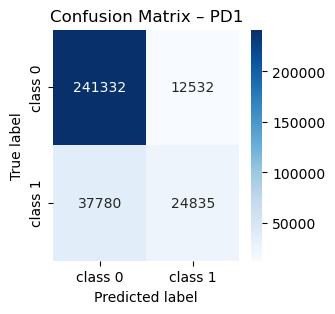

In [48]:
trace_model.eval()
criterion = nn.BCEWithLogitsLoss()

test_loss = 0.0
test_correct = 0
test_total = 0

all_y_true = []
all_y_pred = []

with torch.no_grad():
    for inputs_test, targets_test in test_loader:
        label_test_task = targets_test["ATC"].unsqueeze(1).to(device)

        inputs_test = {k: v.to(device) for k, v in inputs_test.items()}

        delta_elapsed = get_elapsed_feature(inputs_test["timestamps"]).to(device)
        delta_between = get_between_features(inputs_test["timestamps"]).to(device)

        logits = trace_model(
            inputs_test["aid"],
            inputs_test["type"],
            delta_elapsed,
            delta_between
        )

        loss = criterion(logits, label_test_task.float())
        test_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        test_correct += (preds == label_test_task).sum().item()
        test_total += label_test_task.numel()

        all_y_true.append(label_test_task.cpu())
        all_y_pred.append(preds.cpu())


test_loss /= len(test_loader)
test_accuracy = test_correct / max(test_total, 1)

y_true = torch.cat(all_y_true).numpy().astype(int).ravel()
y_pred = torch.cat(all_y_pred).numpy().astype(int).ravel()

f1 = f1_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:\n", cm)
print(classification_report(y_true, y_pred, target_names=["class 0", "class 1"]))

fig = plot_confusion_matrix(
    cm,
    name_task="PD1",
    name_classes=["class 0", "class 1"]
)
plt.show()
plt.close(fig)
